# <a id='toc1_'></a>[<span style='color:yellow;'>Face Sketch Generator</span>](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [<span style='color:yellow;'>Face Sketch Generator</span>](#toc1_)    
- [Step 1: Import Libraries](#toc2_)    
- [Step 2: Load the input image and initialize paths](#toc3_)    
  - [Step 2.1: Define paths for input and output files](#toc3_1_)    
  - [Step 2.2: Load the image using OpenCV](#toc3_2_)    
  - [Step 2.3: Print information about the original image for debugging/understanding](#toc3_3_)    
- [Step 3: Convert to grayscale](#toc4_)    
  - [Step 3.1: Convert the color image to grayscale](#toc4_1_)    
  - [Step 3.2: Print information about the grayscale image](#toc4_2_)    
  - [Step 3.3: Display the grayscale image](#toc4_3_)    
- [Step 4: Reduce noise with Gaussian blur](#toc5_)    
  - [Step 4.1: Apply Gaussian blur to reduce high-frequency noise](#toc5_1_)    
  - [Step 4.2: Print information about the blurred image](#toc5_2_)    
  - [Step 4.3: Display the blurred image](#toc5_3_)    
- [Step 5: Detect edges with Canny](#toc6_)    
  - [Step 5.1: Adjusted thresholds to preserve outer edges](#toc6_1_)    
  - [Step 5.2: Dilate edges slightly to thicken thin/weak outer contours](#toc6_2_)    
  - [Step 5.3: Print information about the edge detection result](#toc6_3_)    
  - [Step 5.4: Display the detected edges](#toc6_4_)    
- [Step 6: Invert edges for sketch-like appearance](#toc7_)    
  - [Step 6.1: Invert the edge image](#toc7_1_)    
  - [Step 6.2: Print information about the inverted edges](#toc7_2_)    
  - [Step 6.3: Display the inverted edges](#toc7_3_)    
- [Step 7: Create light gray base for shading](#toc8_)    
  - [Step 7.1: Create a light gray version of the original grayscale image to mimic pencil shading](#toc8_1_)    
  - [Step 7.2: Print information about the light gray base](#toc8_2_)    
  - [Step 7.3: Display the light gray base](#toc8_3_)    
- [Step 8: Combine elements to create final sketch](#toc9_)    
  - [Step 8.1: Use bitwise AND with inverted edges as a mask to combine shading and edges](#toc9_1_)    
  - [Step 8.2: Print information about the final sketch](#toc9_2_)    
  - [Step 8.3: Save the final sketch to a file](#toc9_3_)    
  - [Step 8.4: Display the final sketch](#toc9_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Step 1: Import Libraries](#toc0_)

In [1]:
# This command ensures images are shown directly in the notebook output
%matplotlib inline

In [2]:
# Import required libraries
import cv2                  # OpenCV for image processing
import numpy as np          # NumPy for numerical operations on images
import matplotlib.pyplot as plt  # Matplotlib for displaying images

# <a id='toc3_'></a>[Step 2: Load the input image and initialize paths](#toc0_)

## <a id='toc3_1_'></a>[Step 2.1: Define paths for input and output files](#toc0_)

In [3]:
input_image_path = "Jerry.jpg"   # Path to your cat face image
output_image_path = "Jerry_sketch_final.jpg"  # Path to save the final sketch

## <a id='toc3_2_'></a>[Step 2.2: Load the image using OpenCV](#toc0_)

In [4]:
# Note: OpenCV reads images in BGR color format by default (not RGB)
image = cv2.imread(input_image_path)

In [5]:
# Check if the image loaded successfully
if image is None:
    # Raise an error if the image couldn't be loaded (e.g., wrong path)
    raise ValueError(f"Error: Could not load image from path: {input_image_path}")

## <a id='toc3_3_'></a>[Step 2.3: Print information about the original image for debugging/understanding](#toc0_)

In [6]:
print("=== Original Image Information ===")
print(f"Data type: {type(image)} (OpenCV image is a NumPy array)")
print(f"Dimensions: {image.shape} (height, width, color channels)")
print(f"Pixel data type: {image.dtype} (usually uint8 for 0-255 pixel values)")
print(f"Pixel value range: [{np.min(image)} - {np.max(image)}] (0=black, 255=white)\n")

=== Original Image Information ===
Data type: <class 'numpy.ndarray'> (OpenCV image is a NumPy array)
Dimensions: (3264, 2448, 3) (height, width, color channels)
Pixel data type: uint8 (usually uint8 for 0-255 pixel values)
Pixel value range: [0 - 255] (0=black, 255=white)



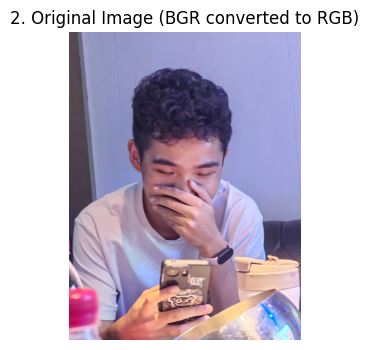

In [7]:
# Display the original image using Matplotlib
# Convert BGR to RGB first because Matplotlib expects RGB format
plt.figure(figsize=(6, 4))  # Set figure size (width, height) in inches
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert color format
plt.title("2. Original Image (BGR converted to RGB)")  # Add title
plt.axis('off')  # Hide axis ticks and labels
plt.show()       # Display the image

# <a id='toc4_'></a>[Step 3: Convert to grayscale](#toc0_)

## <a id='toc4_1_'></a>[Step 3.1: Convert the color image to grayscale](#toc0_)

In [8]:
# (removes color channels)
# Grayscale simplifies processing 
# since edge detection doesn't need color information
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

## <a id='toc4_2_'></a>[Step 3.2: Print information about the grayscale image](#toc0_)

In [9]:
print("\n=== Grayscale Image Information ===")
print(f"Data type: {type(gray_image)}")
print(f"Dimensions: {gray_image.shape} (height, width - no color channels)")
print(f"Pixel value range: [{np.min(gray_image)} - {np.max(gray_image)}]")


=== Grayscale Image Information ===
Data type: <class 'numpy.ndarray'>
Dimensions: (3264, 2448) (height, width - no color channels)
Pixel value range: [7 - 255]


## <a id='toc4_3_'></a>[Step 3.3: Display the grayscale image](#toc0_)

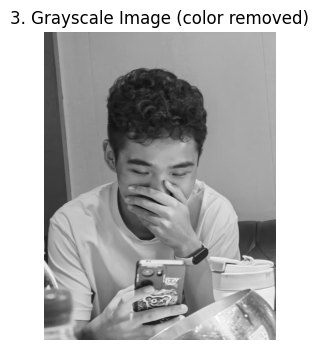

In [10]:
# (use 'gray' colormap for proper rendering)
plt.figure(figsize=(6, 4))
plt.imshow(gray_image, cmap='gray')  # 'gray' colormap ensures correct grayscale display
plt.title("3. Grayscale Image (color removed)")
plt.axis('off')
plt.show()

# <a id='toc5_'></a>[Step 4: Reduce noise with Gaussian blur](#toc0_)

## <a id='toc5_1_'></a>[Step 4.1: Apply Gaussian blur to reduce high-frequency noise](#toc0_)

In [11]:
# (small details that aren't edges)
# Kernel size (7,7): Larger kernel = more blur (balance between noise reduction and edge preservation)
# Sigma=0: Automatically calculate sigma based on kernel size
blurred_image = cv2.GaussianBlur(gray_image, (7, 7), 0)

## <a id='toc5_2_'></a>[Step 4.2: Print information about the blurred image](#toc0_)

In [12]:
print("\n=== Blurred Image Information ===")
print(f"Data type: {type(blurred_image)}")
print(f"Dimensions: {blurred_image.shape}")
print(f"Blur kernel size: (7, 7) (larger than default to reduce noise while preserving edges)")
print(f"Pixel value range: [{np.min(blurred_image)} - {np.max(blurred_image)}]")


=== Blurred Image Information ===
Data type: <class 'numpy.ndarray'>
Dimensions: (3264, 2448)
Blur kernel size: (7, 7) (larger than default to reduce noise while preserving edges)
Pixel value range: [12 - 255]


## <a id='toc5_3_'></a>[Step 4.3: Display the blurred image](#toc0_)

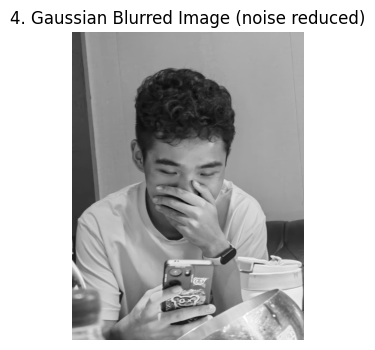

In [13]:
plt.figure(figsize=(6, 4))
plt.imshow(blurred_image, cmap='gray')
plt.title("4. Gaussian Blurred Image (noise reduced)")
plt.axis('off')
plt.show()

# <a id='toc6_'></a>[Step 5: Detect edges with Canny](#toc0_)

In [14]:
# Canny edge detection works by:
# 1. Finding areas with rapid intensity changes (potential edges)
# 2. Using two thresholds to classify edges as strong (above threshold2), weak (between thresholds), or non-edges (below threshold1)
# 3. Retaining weak edges only if they're connected to strong edges

## <a id='toc6_1_'></a>[Step 5.1: Adjusted thresholds to preserve outer edges](#toc0_)

In [15]:
# (lower values = more edges detected)
# threshold1=10: Lower bound for weak edges
# threshold2=50: Upper bound for strong edges
edges = cv2.Canny(blurred_image, threshold1=10, threshold2=50)

## <a id='toc6_2_'></a>[Step 5.2: Dilate edges slightly to thicken thin/weak outer contours](#toc0_)

In [16]:
# Kernel (2,2): Small kernel to avoid excessive thickening
# iterations=1: Single pass for subtle thickening
kernel = np.ones((2, 2), np.uint8)  # Create a 2x2 matrix of 1s
edges = cv2.dilate(edges, kernel, iterations=1)  # Thicken edges

## <a id='toc6_3_'></a>[Step 5.3: Print information about the edge detection result](#toc0_)

In [17]:
print("\n=== Edge Detection Information ===")
print(f"Data type: {type(edges)}")
print(f"Dimensions: {edges.shape}")
print(f"Canny thresholds: (10, 50) (lowered to capture more outer edges)")
print(f"Total edge pixels: {np.count_nonzero(edges)} (white pixels representing edges)")


=== Edge Detection Information ===
Data type: <class 'numpy.ndarray'>
Dimensions: (3264, 2448)
Canny thresholds: (10, 50) (lowered to capture more outer edges)
Total edge pixels: 229795 (white pixels representing edges)


## <a id='toc6_4_'></a>[Step 5.4: Display the detected edges](#toc0_)

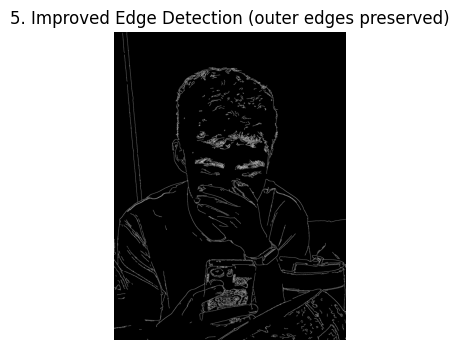

In [18]:
plt.figure(figsize=(6, 4))
plt.imshow(edges, cmap='gray')
plt.title("5. Improved Edge Detection (outer edges preserved)")
plt.axis('off')
plt.show()

# <a id='toc7_'></a>[Step 6: Invert edges for sketch-like appearance](#toc0_)

## <a id='toc7_1_'></a>[Step 6.1: Invert the edge image](#toc0_)

In [19]:
# to get white edges on a black background (traditional sketch style)
# 255 - edges: Converts black (0) to white (255) and white (255) to black (0)
inverted_edges = 255 - edges

## <a id='toc7_2_'></a>[Step 6.2: Print information about the inverted edges](#toc0_)

In [20]:
print("\n=== Inverted Edges Information ===")
print(f"Data type: {type(inverted_edges)}")
print(f"Dimensions: {inverted_edges.shape}")
print(f"Pixel value range: [{np.min(inverted_edges)} - {np.max(inverted_edges)}]")


=== Inverted Edges Information ===
Data type: <class 'numpy.ndarray'>
Dimensions: (3264, 2448)
Pixel value range: [0 - 255]


## <a id='toc7_3_'></a>[Step 6.3: Display the inverted edges](#toc0_)

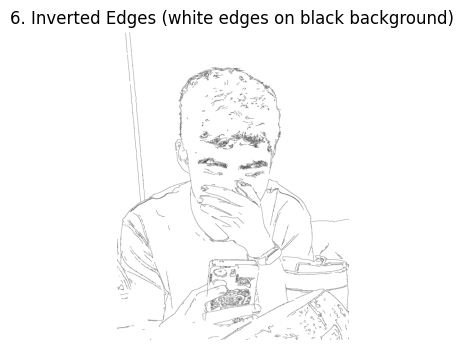

In [21]:
plt.figure(figsize=(6, 4))
plt.imshow(inverted_edges, cmap='gray')
plt.title("6. Inverted Edges (white edges on black background)")
plt.axis('off')
plt.show()

# <a id='toc8_'></a>[Step 7: Create light gray base for shading](#toc0_)

## <a id='toc8_1_'></a>[Step 7.1: Create a light gray version of the original grayscale image to mimic pencil shading](#toc0_)

* `cv2.addWeighted()` formula: $$dst = alpha\times src1 + beta\times src2 + gamma$$
* $alpha=0.3$: Weight for grayscale image (dims down the intensity)
* $beta=0$: Weight for the second image (all zeros, so no contribution)
* $gamma=20$: Brightness adjustment (adds 20 to all pixels)

In [22]:
light_gray = cv2.addWeighted(gray_image, 0.4, np.zeros_like(gray_image), 0, 40)

## <a id='toc8_2_'></a>[Step 7.2: Print information about the light gray base](#toc0_)

In [23]:
print("\n=== Light Gray Base Information ===")
print(f"Data type: {type(light_gray)}")
print(f"Dimensions: {light_gray.shape}")
print(f"Parameters: alpha=0.3 (grayscale weight), gamma=20 (brightness boost)")
print(f"Pixel value range: [{np.min(light_gray)} - {np.max(light_gray)}]")


=== Light Gray Base Information ===
Data type: <class 'numpy.ndarray'>
Dimensions: (3264, 2448)
Parameters: alpha=0.3 (grayscale weight), gamma=20 (brightness boost)
Pixel value range: [43 - 142]


## <a id='toc8_3_'></a>[Step 7.3: Display the light gray base](#toc0_)

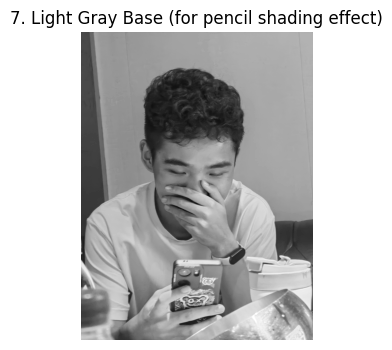

In [24]:
plt.figure(figsize=(6, 4))
plt.imshow(light_gray, cmap='gray')
plt.title("7. Light Gray Base (for pencil shading effect)")
plt.axis('off')
plt.show()

# <a id='toc9_'></a>[Step 8: Combine elements to create final sketch](#toc0_)

## <a id='toc9_1_'></a>[Step 8.1: Use bitwise AND with inverted edges as a mask to combine shading and edges](#toc0_)

In [25]:
# The mask (inverted_edges) ensures edges stay white while the rest uses the light gray shading
final_sketch = cv2.bitwise_and(light_gray, light_gray, mask=inverted_edges)

## <a id='toc9_2_'></a>[Step 8.2: Print information about the final sketch](#toc0_)

In [26]:
print("\n=== Final Sketch Information ===")
print(f"Data type: {type(final_sketch)}")
print(f"Dimensions: {final_sketch.shape}")
print(f"Output file saved to: {output_image_path}")


=== Final Sketch Information ===
Data type: <class 'numpy.ndarray'>
Dimensions: (3264, 2448)
Output file saved to: Jerry_sketch_final.jpg


## <a id='toc9_3_'></a>[Step 8.3: Save the final sketch to a file](#toc0_)

In [27]:
cv2.imwrite(output_image_path, final_sketch)

True

## <a id='toc9_4_'></a>[Step 8.4: Display the final sketch](#toc0_)

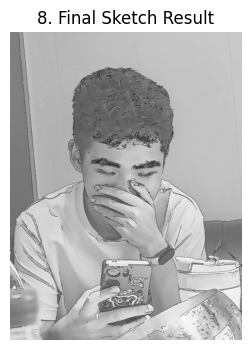

In [28]:
plt.figure(figsize=(6, 4))
plt.imshow(final_sketch, cmap='gray')
plt.title("8. Final Sketch Result")
plt.axis('off')
plt.show()